In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GroupKFold, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import shap

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving health_fitness_dataset.csv to health_fitness_dataset.csv


In [ ]:
fitness_data = pd.read_csv("health_fitness_dataset.csv")
fitness_data.head(10)

,participant_id,date,age,gender,height_cm,weight_kg,activity_type,duration_minutes,intensity,calories_burned,...,stress_level,daily_steps,hydration_level,bmi,resting_heart_rate,blood_pressure_systolic,blood_pressure_diastolic,health_condition,smoking_status,fitness_level
0,1,2024-01-01,56,F,165.3,53.7,Dancing,41,Low,3.3,...,3,7128,1.5,19.6,69.5,110.7,72.9,NaN,Never,0.04
1,1,2024-01-04,56,F,165.3,53.9,Swimming,28,Low,2.9,...,7,7925,1.8,19.6,69.5,110.7,72.9,NaN,Never,0.07
2,1,2024-01-05,56,F,165.3,54.2,Swimming,21,Medium,2.6,...,7,7557,2.7,19.6,69.5,110.7,72.9,NaN,Never,0.09
3,1,2024-01-07,56,F,165.3,54.4,Weight Training,99,Medium,10.7,...,8,11120,2.6,19.6,69.5,110.7,72.9,NaN,Never,0.21
4,1,2024-01-09,56,F,165.3,54.7,Swimming,100,Medium,12.7,...,1,5406,1.5,19.6,69.5,110.7,72.9,NaN,Never,0.33
5,1,2024-01-10,56,F,165.3,54.9,HIIT,31,Medium,6.8,...,10,10202,2.2,19.6,69.5,110.7,72.9,NaN,Never,0.37
6,1,2024-01-11,56,F,165.3,55.2,Weight Training,97,High,12.4,...,8,5912,2.8,19.6,69.5,110.7,72.9,NaN,Never,0.51
7,1,2024-01-12,56,F,165.3,55.5,HIIT,70,Low,12.9,...,7,9477,1.6,19.6,69.5,110.7,72.9,NaN,Never,0.58
8,1,2024-01-17,56,F,165.3,55.7,HIIT,89,Medium,19.7,...,7,9710,3.3,19.6,69.5,110.7,72.9,NaN,Never,0.68
9,1,2024-01-18,56,F,165.3,56.0,Weight Training,115,Medium,12.8,...,3,7830,2.0,19.6,69.5,110.7,72.9,NaN,Never,0.82


In [ ]:
# Check Data types
print('data types:\n', fitness_data.dtypes)


data types:
 participant_id                int64
date                         object
age                           int64
gender                       object
height_cm                   float64
weight_kg                   float64
activity_type                object
duration_minutes              int64
intensity                    object
calories_burned             float64
avg_heart_rate                int64
hours_sleep                 float64
stress_level                  int64
daily_steps                   int64
hydration_level             float64
bmi                         float64
resting_heart_rate          float64
blood_pressure_systolic     float64
blood_pressure_diastolic    float64
health_condition             object
smoking_status               object
fitness_level               float64
dtype: object


In [ ]:
# Identify Missing Values

print('Missing values:\n', fitness_data.isnull().sum())

Missing values:
 participant_id                   0
date                             0
age                              0
gender                           0
height_cm                        0
weight_kg                        0
activity_type                    0
duration_minutes                 0
intensity                        0
calories_burned                  0
avg_heart_rate                   0
hours_sleep                      0
stress_level                     0
daily_steps                      0
hydration_level                  0
bmi                              0
resting_heart_rate               0
blood_pressure_systolic          0
blood_pressure_diastolic         0
health_condition            490275
smoking_status                   0
fitness_level                    0
dtype: int64


In [ ]:
# Handle Missing Values
# Since a large amount of data for health_condition is missing so we drop the entire column

fitness_data = fitness_data.drop(columns=['health_condition'])

# Missing values count after removing the column
print('Missing Values:', fitness_data.isnull().sum());


Missing Values: participant_id              0
date                        0
age                         0
gender                      0
height_cm                   0
weight_kg                   0
activity_type               0
duration_minutes            0
intensity                   0
calories_burned             0
avg_heart_rate              0
hours_sleep                 0
stress_level                0
daily_steps                 0
hydration_level             0
bmi                         0
resting_heart_rate          0
blood_pressure_systolic     0
blood_pressure_diastolic    0
smoking_status              0
fitness_level               0
dtype: int64


In [ ]:
# Prints the number of rows in the dataset
print("Rows:", len(fitness_data))

# Prints the number of unique participants
print("Unique participants:", fitness_data['participant_id'].nunique())

Rows: 687701
Unique participants: 3000


**Step:** **Feature Selection**




In [ ]:
# Set target variable
TARGET = "calories_burned"

**Step:** **Pre-Processing**

In [ ]:
# Identify numeric and categorical columns

numerical_cols = [
    'age', 'height_cm', 'weight_kg', 'duration_minutes',
    'avg_heart_rate', 'hours_sleep', 'stress_level',
    'daily_steps', 'hydration_level', 'bmi',
    'resting_heart_rate', 'blood_pressure_systolic',
    'blood_pressure_diastolic', 'fitness_level'
]
categorical_cols = [
    'gender', 'activity_type', 'intensity', 'smoking_status'
]

In [ ]:
# We convert date into datetime so that we can create day_of_week and is_weekend features

fitness_data['date'] = pd.to_datetime(fitness_data['date'])
print('data types:\n', fitness_data.dtypes)

fitness_data['day_of_week'] = fitness_data['date'].dt.weekday
fitness_data['is_weekend'] = fitness_data['day_of_week'].isin([5,6]).astype(int)
numerical_cols.extend(['day_of_week', 'is_weekend'])
fitness_data.head()

data types:
 participant_id                       int64
date                        datetime64[ns]
age                                  int64
gender                              object
height_cm                          float64
weight_kg                          float64
activity_type                       object
duration_minutes                     int64
intensity                           object
calories_burned                    float64
avg_heart_rate                       int64
hours_sleep                        float64
stress_level                         int64
daily_steps                          int64
hydration_level                    float64
bmi                                float64
resting_heart_rate                 float64
blood_pressure_systolic            float64
blood_pressure_diastolic           float64
smoking_status                      object
fitness_level                      float64
dtype: object


,participant_id,date,age,gender,height_cm,weight_kg,activity_type,duration_minutes,intensity,calories_burned,...,daily_steps,hydration_level,bmi,resting_heart_rate,blood_pressure_systolic,blood_pressure_diastolic,smoking_status,fitness_level,day_of_week,is_weekend
0,1,2024-01-01,56,F,165.3,53.7,Dancing,41,Low,3.3,...,7128,1.5,19.6,69.5,110.7,72.9,Never,0.04,0,0
1,1,2024-01-04,56,F,165.3,53.9,Swimming,28,Low,2.9,...,7925,1.8,19.6,69.5,110.7,72.9,Never,0.07,3,0
2,1,2024-01-05,56,F,165.3,54.2,Swimming,21,Medium,2.6,...,7557,2.7,19.6,69.5,110.7,72.9,Never,0.09,4,0
3,1,2024-01-07,56,F,165.3,54.4,Weight Training,99,Medium,10.7,...,11120,2.6,19.6,69.5,110.7,72.9,Never,0.21,6,1
4,1,2024-01-09,56,F,165.3,54.7,Swimming,100,Medium,12.7,...,5406,1.5,19.6,69.5,110.7,72.9,Never,0.33,1,0


In [ ]:
df_model = fitness_data[numerical_cols + categorical_cols + ['participant_id', 'date', TARGET]].copy()
df_model.info()
df_model.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 687701 entries, 0 to 687700
Data columns (total 23 columns):
 #   Column                    Non-Null Count   Dtype         
---  ------                    --------------   -----         
 0   age                       687701 non-null  int64         
 1   height_cm                 687701 non-null  float64       
 2   weight_kg                 687701 non-null  float64       
 3   duration_minutes          687701 non-null  int64         
 4   avg_heart_rate            687701 non-null  int64         
 5   hours_sleep               687701 non-null  float64       
 6   stress_level              687701 non-null  int64         
 7   daily_steps               687701 non-null  int64         
 8   hydration_level           687701 non-null  float64       
 9   bmi                       687701 non-null  float64       
 10  resting_heart_rate        687701 non-null  float64       
 11  blood_pressure_systolic   687701 non-null  float64       
 12  bl

,age,height_cm,weight_kg,duration_minutes,avg_heart_rate,hours_sleep,stress_level,daily_steps,hydration_level,bmi,...,fitness_level,day_of_week,is_weekend,gender,activity_type,intensity,smoking_status,participant_id,date,calories_burned
0,56,165.3,53.7,41,103,6.6,3,7128,1.5,19.6,...,0.04,0,0,F,Dancing,Low,Never,1,2024-01-01,3.3
1,56,165.3,53.9,28,102,8.1,7,7925,1.8,19.6,...,0.07,3,0,F,Swimming,Low,Never,1,2024-01-04,2.9
2,56,165.3,54.2,21,126,6.2,7,7557,2.7,19.6,...,0.09,4,0,F,Swimming,Medium,Never,1,2024-01-05,2.6
3,56,165.3,54.4,99,141,7.2,8,11120,2.6,19.6,...,0.21,6,1,F,Weight Training,Medium,Never,1,2024-01-07,10.7
4,56,165.3,54.7,100,112,7.1,1,5406,1.5,19.6,...,0.33,1,0,F,Swimming,Medium,Never,1,2024-01-09,12.7


**Step**: **Sort by User and Date**

In [ ]:
df_model = df_model.sort_values(by=['participant_id', 'date'])

**Rolling Average per participant**


In [ ]:
# Find 3 and 7 day rolling average for a participant.
# It gives a better understanding of the participant's average calorie burnt rather than single day values
rolling_cols = [
    'daily_steps',
    'hours_sleep',
    'duration_minutes',
    'avg_heart_rate',
    'resting_heart_rate'
]

for col in rolling_cols:
    df_model[f'{col}_3day_avg'] = (
        df_model.groupby('participant_id')[col]
        .rolling(3, min_periods=1)
        .mean()
        .reset_index(level=0, drop=True)
    )

    df_model[f'{col}_7day_avg'] = (
        df_model.groupby('participant_id')[col]
        .rolling(7, min_periods=1)
        .mean()
        .reset_index(level=0, drop=True)
    )

# Add new rolling features to num_features
for col in rolling_cols:
    numerical_cols.append(f'{col}_3day_avg')
    numerical_cols.append(f'{col}_7day_avg')

**Build X and y**

In [ ]:
# date NOT included as a feature
X = df_model[numerical_cols + categorical_cols]
y = df_model[TARGET]
groups = df_model['participant_id']

X.shape, y.shape

((687701, 30), (687701,))

In [ ]:
df_model.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 687701 entries, 0 to 687700
Data columns (total 33 columns):
 #   Column                       Non-Null Count   Dtype         
---  ------                       --------------   -----         
 0   age                          687701 non-null  int64         
 1   height_cm                    687701 non-null  float64       
 2   weight_kg                    687701 non-null  float64       
 3   duration_minutes             687701 non-null  int64         
 4   avg_heart_rate               687701 non-null  int64         
 5   hours_sleep                  687701 non-null  float64       
 6   stress_level                 687701 non-null  int64         
 7   daily_steps                  687701 non-null  int64         
 8   hydration_level              687701 non-null  float64       
 9   bmi                          687701 non-null  float64       
 10  resting_heart_rate           687701 non-null  float64       
 11  blood_pressure_systolic   

In [ ]:
from sklearn.model_selection import GroupShuffleSplit

# We use GroupShuffleSplit so that same participant doesn't appear in both train and test

gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(X, y, groups))

X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

print("Train size:", X_train.shape)
print("Test size:", X_test.shape)


Train size: (550324, 30)
Test size: (137377, 30)


In [ ]:
# Build preprocessing Transformers
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

numeric_transformer = Pipeline(steps=[
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numerical_cols),
        ('cat', categorical_transformer, categorical_cols)
    ]
)

In [ ]:
# Linear Regression Model
from sklearn.linear_model import LinearRegression

lr_model = Pipeline(steps=[
    ('preprocess', preprocessor),
    ('model', LinearRegression())
])

lr_model

Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('scaler',
                                                                   StandardScaler())]),
                                                  ['age', 'height_cm',
                                                   'weight_kg',
                                                   'duration_minutes',
                                                   'avg_heart_rate',
                                                   'hours_sleep',
                                                   'stress_level',
                                                   'daily_steps',
                                                   'hydration_level', 'bmi',
                                                   'resting_heart_rate',
                                                   'blood_pressure_systolic',
                                                   'blood_pressure_diastolic',
                                                   'fitness_level',
                                                   'day_of_wee...
                                                   'hours_sleep_7day_avg',
                                                   'duration_minutes_3day_avg',
                                                   'duration_minutes_7day_avg',
                                                   'avg_heart_rate_3day_avg',
                                                   'avg_heart_rate_7day_avg',
                                                   'resting_heart_rate_3day_avg',
                                                   'resting_heart_rate_7day_avg']),
                                                 ('cat',
                                                  Pipeline(steps=[('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['gender', 'activity_type',
                                                   'intensity',
                                                   'smoking_status'])])),
                ('model', LinearRegression())])

In [ ]:
lr_model.fit(X_train, y_train)

lr_preds = lr_model.predict(X_test)

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Evaluate performance metrics

lr_mae = mean_absolute_error(y_test, lr_preds)
lr_rmse = np.sqrt(mean_squared_error(y_test, lr_preds))
lr_r2 = r2_score(y_test, lr_preds)

print("Linear Regression Performance:")
print(f"MAE  : {lr_mae:.2f}")
print(f"RMSE : {lr_rmse:.2f}")
print(f"R^2  : {lr_r2:.3f}")

Linear Regression Performance:
MAE  : 2.31
RMSE : 11.08
R^2  : 0.889


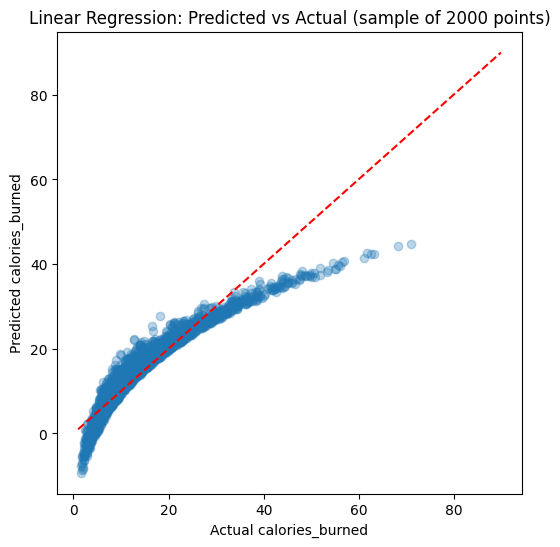

In [ ]:
import matplotlib.pyplot as plt

# Visualize Results Actual vs Predicted

plt.figure(figsize=(6,6))
plt.scatter(y_test[:2000], lr_preds[:2000], alpha=0.3)
plt.xlabel("Actual calories_burned")
plt.ylabel("Predicted calories_burned")
plt.title("Linear Regression: Predicted vs Actual (sample of 2000 points)")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.show()

**Linear Regression Results and Interpretation**

- **Performance**: MAE 2.31 kcal, RMSE 11.08 kcal, R^2 0.889 on the hold-out set (avg absolute error is a couple kcal, but larger misses drive RMSE higher).
- **Interpretation**: The model captures about 89% of outcome variance, yet the scatter plot shows residual under/over-predictions at the extremes because a single linear plane cannot model all feature interactions.
- **Role**: Serves as the transparent baseline—fast to train, coefficient-driven, and the reference that tree models should beat on MAE/RMSE.


**Random Forest Regressor**

In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV

# Creates pipeline for RandomForest

rf_model = Pipeline(steps=[
    ('preprocess', preprocessor),
    ('model', RandomForestRegressor(
        random_state=42,
        n_jobs=-1
    ))
])

rf_model

Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('scaler',
                                                                   StandardScaler())]),
                                                  ['age', 'height_cm',
                                                   'weight_kg',
                                                   'duration_minutes',
                                                   'avg_heart_rate',
                                                   'hours_sleep',
                                                   'stress_level',
                                                   'daily_steps',
                                                   'hydration_level', 'bmi',
                                                   'resting_heart_rate',
                                                   'blood_pressure_systolic',
                                                   'blood_pressure_diastolic',
                                                   'fitness_level',
                                                   'day_of_wee...
                                                   'duration_minutes_3day_avg',
                                                   'duration_minutes_7day_avg',
                                                   'avg_heart_rate_3day_avg',
                                                   'avg_heart_rate_7day_avg',
                                                   'resting_heart_rate_3day_avg',
                                                   'resting_heart_rate_7day_avg']),
                                                 ('cat',
                                                  Pipeline(steps=[('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['gender', 'activity_type',
                                                   'intensity',
                                                   'smoking_status'])])),
                ('model', RandomForestRegressor(n_jobs=-1, random_state=42))])

In [ ]:
# Create a small susbset from training data to reduce model build time.

from sklearn.model_selection import train_test_split

X_tune, _, y_tune, _ = train_test_split(
    X_train, y_train,
    test_size=0.9,
    random_state=42
)

print("Tuning subset shape:", X_tune.shape, y_tune.shape)


Tuning subset shape: (55032, 30) (55032,)


In [ ]:
# Below was our initial model but in order to reduce the model build time we made our hyperparameters smaller

# rf_param_grid = {
#     'model__n_estimators': [100, 200],
#     'model__max_depth': [None, 10],
#     'model__min_samples_split': [2, 5]
# }

# model_n_estimators indicate the number of trees
# model max depth indicates the maximum level of splits
# min sample split indicates the minimum number of data points needed before a node is allowed to split

rf_param_grid_6fits = {
    'model__n_estimators': [150],     # 1 value
    'model__max_depth': [None, 12],   # 2 values
    'model__min_samples_split': [2]  # 1 value
}

In [ ]:
rf_grid = GridSearchCV(
    rf_model,
    rf_param_grid_6fits,
    cv=3,
    scoring='neg_mean_absolute_error',
    n_jobs=-1,
    verbose=2
)

rf_grid.fit(X_tune, y_tune)

Fitting 3 folds for each of 2 candidates, totalling 6 fits


GridSearchCV(cv=3,
             estimator=Pipeline(steps=[('preprocess',
                                        ColumnTransformer(transformers=[('num',
                                                                         Pipeline(steps=[('scaler',
                                                                                          StandardScaler())]),
                                                                         ['age',
                                                                          'height_cm',
                                                                          'weight_kg',
                                                                          'duration_minutes',
                                                                          'avg_heart_rate',
                                                                          'hours_sleep',
                                                                          'stress_level',
                                                                          'daily_steps',
                                                                          'hydration_level',
                                                                          'bmi',
                                                                          'resting_heart_rate',
                                                                          'blood_pressure_systolic',
                                                                          'blood_pressure_diastolic'...
                                                                        ('cat',
                                                                         Pipeline(steps=[('onehot',
                                                                                          OneHotEncoder(handle_unknown='ignore'))]),
                                                                         ['gender',
                                                                          'activity_type',
                                                                          'intensity',
                                                                          'smoking_status'])])),
                                       ('model',
                                        RandomForestRegressor(n_jobs=-1,
                                                              random_state=42))]),
             n_jobs=-1,
             param_grid={'model__max_depth': [None, 12],
                         'model__min_samples_split': [2],
                         'model__n_estimators': [150]},
             scoring='neg_mean_absolute_error', verbose=2)

In [ ]:
# Gives the best model
rf_best = rf_grid.best_estimator_
rf_grid.best_params_

{'model__max_depth': None,
 'model__min_samples_split': 2,
 'model__n_estimators': 150}

In [ ]:
rf_preds = rf_best.predict(X_test)

In [ ]:
# Evaluate Performance
rf_mae = mean_absolute_error(y_test, rf_preds)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_preds))
rf_r2 = r2_score(y_test, rf_preds)

print("Random Forest Performance:")
print(f"MAE  : {rf_mae:.2f}")
print(f"RMSE : {rf_rmse:.2f}")
print(f"R^2  : {rf_r2:.3f}")

Random Forest Performance:
MAE  : 0.25
RMSE : 0.47
R^2  : 0.998


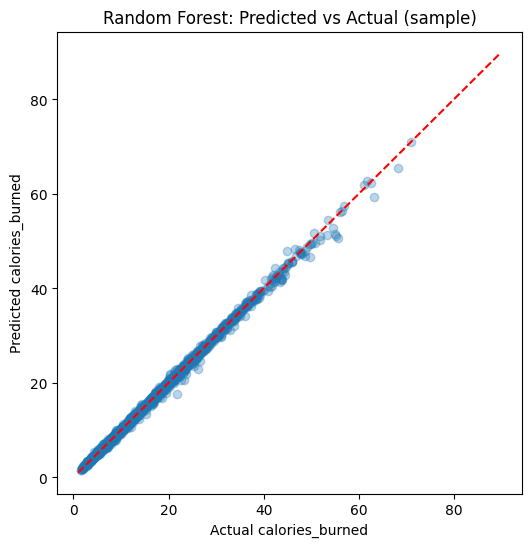

In [ ]:
# Visualize Results Actual vs Predicted

plt.figure(figsize=(6,6))
plt.scatter(y_test[:2000], rf_preds[:2000], alpha=0.3)
plt.xlabel("Actual calories_burned")
plt.ylabel("Predicted calories_burned")
plt.title("Random Forest: Predicted vs Actual (sample)")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.show()

**Random Forest Results**

- **Performance**: MAE 0.25 kcal, RMSE 0.47 kcal, R^2 0.998 on the test set
- **Interpretation**: ~150 trees (depth None/12) capture non-linear splits across steps, heart rate, and sleep; ensemble averaging smooths noise and makes it more robust to outliers than Linear Regression.
- **Scatter plot**: points sit tightly around the 45° line, indicating well-calibrated predictions across the range without the extreme tightness of boosting.
- **Usage**: strong balance of accuracy and robustness with feature importance for interpretability; suitable for near-best performance without tuning sensitivity.


In [ ]:
# Gradient Boosting Model
from sklearn.ensemble import GradientBoostingRegressor
import numpy as np

# Create Gradient Boosting pipeline 
gb_model = Pipeline([
    ('preprocess', preprocessor),
    ('model', GradientBoostingRegressor(
        n_estimators=100,
        max_depth=5,
        learning_rate=0.1,
        min_samples_split=5,
        random_state=42
    ))
])

print("Training Gradient Boosting Model...")
gb_model.fit(X_train, y_train)
print("Training completed!")

Training Gradient Boosting Model...
Training completed!


In [ ]:
gb_best = gb_model
print("Gradient Boosting model trained with parameters:")
print(f"  n_estimators: 100")
print(f"  max_depth: 5")
print(f"  learning_rate: 0.1")
print(f"  min_samples_split: 5")

Gradient Boosting model trained with parameters:
  n_estimators: 100
  max_depth: 5
  learning_rate: 0.1
  min_samples_split: 5


In [ ]:
# Make predictions
gb_preds = gb_best.predict(X_test)

In [ ]:
# Calculate metrics
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

gb_mae = mean_absolute_error(y_test, gb_preds)
gb_rmse = np.sqrt(mean_squared_error(y_test, gb_preds))
gb_r2 = r2_score(y_test, gb_preds)

print("Gradient Boosting Performance:")
print(f"MAE  : {gb_mae:.2f}")
print(f"RMSE : {gb_rmse:.2f}")
print(f"R^2  : {gb_r2:.3f}")


Gradient Boosting Performance:
MAE  : 0.35
RMSE : 0.47
R^2  : 0.998


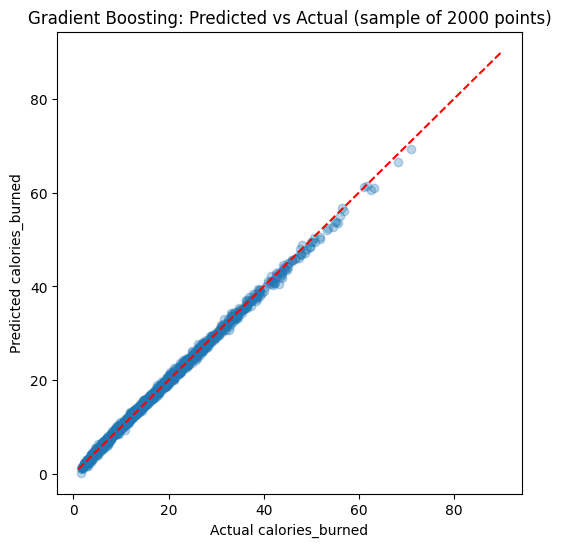

In [ ]:
# Plot actual vs predicted
plt.figure(figsize=(6,6))
plt.scatter(y_test[:2000], gb_preds[:2000], alpha=0.3)
plt.xlabel("Actual calories_burned")
plt.ylabel("Predicted calories_burned")
plt.title("Gradient Boosting: Predicted vs Actual (sample of 2000 points)")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.show()

**Gradient Boosting Model Results**

- Performance: MAE 0.35 kcal, RMSE 0.47 kcal, R^2 0.998 on the test set—sub-kcal error and nearly all variance explained.
- Interpretation: stage-wise trees captured subtle non-linear interactions (steps, active minutes, sleep) and produced a very tight predicted-vs-actual pattern.



**Conclusion**



*   Random Forest delivered the top average accuracy (MAE 0.25, RMSE 0.47, R² 0.998), achieving the lowest prediction error while maintaining an extremely tight predicted-vs-actual fit on the test split.
*   Gradient Boosting matched the R² at 0.998 with MAE 0.35 and RMSE 0.47, confirming excellent predictive power but with slightly higher average error than Random Forest.

*   Linear Regression trailed with MAE 2.31, RMSE 11.08, R² 0.889; it remains the quick, interpretable baseline but is unable to capture the strong non-linear relationships present in the data.

**Efficiency**: Linear Regression trains and predicts fastest; Random Forest offers a balanced trade-off between accuracy and training cost; Gradient Boosting requires additional computation due to its sequential training nature.

**Overall**: Random Forest stands as the leading model in this study, delivering the lowest average error and highly stable performance, while Gradient Boosting serves as a close alternative when marginal accuracy gains are preferred at the cost of additional training time.